<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCP_Teaser.png" width=100% style="float: right;" alt="PCP Teaser"></a>
</div>

# Unit 6: Complex Numbers

<ul>
    <li><a href='#learn' style="color:#E65100;"><strong>Overview and Learning Objectives</strong></a></li>    
    <li><a href='#basic' style="color:black;">Basic Definitions</a></li>
    <li><a href='#polar' style="color:black;">Polar Representation</a></li>
    <li><a href='#operations' style="color:black;">Complex Operations</a></li>
    <li><a href='#polarplot' style="color:black;">Polar Coordinate Plot</a></li>
    <li><a href='#exercise_complex' style="color:#006064;"><strong>Exercise 1:</strong> Rotate Complex Number</a></li>    
    <li><a href='#exercise_polynomial' style="color:#006064;"><strong>Exercise 2:</strong> Roots of Polynomial</a></li>
    <li><a href='#exercise_mandelbrot' style="color:#006064;"><strong>Exercise 3:</strong> Mandelbrot Set</a></li>    
</ul> 

<a id='learn'></a> 
<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<h2 style="color:#E65100;">
Overview and Learning Objectives
</h2>

<p style="color:#E65100;">
As often in mathematics, transferring a problem from the real into the complex world can lead to significant simplifications. At first sight, this may seem a bit surprising since complex numbers are more difficult to understand than real numbers. As an application of complex numbers, let us consider the problem of finding solutions to polynomial equations. The equation $z^2-1=0$ has the two solutions $z=+1$ and $z=-1$ while the equation $z^2+1=0$ does not have any solution when only considering real numbers. Extending $\mathbb{R}$ (the space of real numbers) to $\mathbb{C}$ (the space of complex numbers), however, one also finds for the second equation two solutions given by $z=+i$ and $z=-i$, where $i$ denotes the complex unit. In other words,  considering polynomial equations over $\mathbb{C}$ (rather than  $\mathbb{R}$) makes the problem much easier to understand. In general, an extension of the real numbers to the complex numbers not only gives a broader view but also provides additional tools and structures. We will encounter another application for complex numbers in <a href="PCP_07_exp.html">Unit 7</a>, where we study a complex extension of the exponential function and its relation to trigonometric identities. 
</p>  

<p style="color:#E65100;">
In this unit, we review the basic properties of complex numbers. In particular, we provide Python code examples for visualizing complex numbers using either Cartesian coordinates or polar coordinates. Such visualizations, while being a nice application of the library `matplotlib` introduced in <a href="PCP_05_vis.html">Unit 5</a>, should help you gain a geometric understanding of complex numbers and the effect of their algebraic operations. In <a href='#exercise_complex'>Exercise 1</a>, you will apply previously introduced Python code to rotate complex numbers and visualize the effect. Then, in <a href='#exercise_polynomial'>Exercise 2</a>, we address the problem of finding the roots of a given polynomial using the NumPy function <code>np.roots</code>. The roots' visualizations will give you a feeling of how the roots distribute in the complex plane depending on the polynomials' coefficients. As another application of complex numbers, we discuss in <a href='#exercise_mandelbrot'>Exercise 3</a> how to generate the Mandelbrot set, which is a famous and one of the most beautiful examples for a fractal set. When going through this unit, we recommend that you do the first two exercises while the third exercise is left as a playground for exploring the beauty of fractals and the power of visualizations (e.g., tweaking around with color maps).
</p>  
    
</div>

In [1]:
# --- Core scientific stack ---
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

# --- Custom utilities (Unit 6) ---
from libpcp.unit06 import (
    exercise_complex,
    exercise_polynomial,
    exercise_mandelbrot,
    exercise_mandelbrot_fancy
)

# --- Vectorized figures and font size settings ---
%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({'font.size': 8, 'axes.titlesize': 9})

<a id='basic'></a> 
## Basic Definitions

We can write a complex number $c = a + ib$ with real part $\mathrm{Re}(c) = a$, imaginary part $\mathrm{Im}(c) = b$, and imaginary unit $i = \sqrt{-1}$. In Python, the symbol `j` is used to denote the imaginary unit. Furthermore, a coefficient before `j` is needed. To specify a complex number, one can also use the constructor `complex`.

In [2]:
a = 1.5
b = 0.8
c = a + b*1j
print('c  = ', c, ', type(c)  = ', type(c))
c2 = complex(a,b)
print('c2 = ', c2, ', type(c2) = ', type(c2))

c  =  (1.5+0.8j) , type(c)  =  <class 'complex'>
c2 =  (1.5+0.8j) , type(c2) =  <class 'complex'>


Python offers the built-in `math` package for basic processing of complex numbers. As an alternative, we use here the external package `numpy`, which was introduced in the [PCP notebook on NumPy Basics](PCP_03_numpy.html).

In [3]:
print(np.real(c))
print(np.imag(c))

1.5
0.8


A complex number $c = a+ib$ can be plotted as a point $(a,b)$ in the Cartesian coordinate system. This point is often visualized by an arrow starting at $(0,0)$ and ending at $(a,b)$. The next code cell serves the following purposes: 

* We provide a function `plot_vector` for plotting such an arrow for a given complex number $c$.
* We provide a function `generate_figure` used to open a figure with adjusted x- and y-axes. 
* We show how to apply the functions and how to place text elements in the figure.

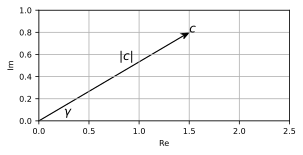

In [4]:
def generate_figure(figsize=(4.5, 2.0), xlim=[0, 1], ylim=[0, 1]):
    """Generate figure for plotting complex numbers

    Notebook: PCP_06_complex.ipynb

    Args:
       figsize: Width, height in inches (Default value = (2, 2))
       xlim: Limits for x-axis (Default value = [0, 1])
       ylim: Limits for y-axis (Default value = [0, 1])
    """
    plt.figure(figsize=figsize)
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(r'$\mathrm{Re}$')
    plt.ylabel(r'$\mathrm{Im}$')

def plot_vector(c, color='k', start=0, linestyle='-'):
    """Plot arrow corresponding to difference of two complex numbers

    Notebook: PCP_06_complex.ipynb

    Args:
        c: Complex number
        color: Color of arrow (Default value = 'k')
        start: Complex number encoding the start position (Default value = 0)
        linestyle: Linestyle of arrow (Default value = '-')

    Returns:
        plt.arrow: matplotlib.patches.FancyArrow
    """
    return plt.arrow(np.real(start), np.imag(start), np.real(c), np.imag(c),
                     linestyle=linestyle, head_width=0.05,
                     fc=color, ec=color, overhang=0.3, length_includes_head=True)
    

c = 1.5 + 0.8j

generate_figure(xlim=[0, 2.5], ylim=[0, 1])
v = plot_vector(c, color='k')
plt.text(1.5, 0.8, '$c$', fontsize=12)
plt.text(0.8, 0.55, '$|c|$', fontsize=12)
plt.text(0.25, 0.05, r'$\gamma$', fontsize=12);

<a id='polar'></a> 
## Polar Representation

The **absolute value** (or **modulus**) of a complex number $a+ib$ is defined by

$$|c| := \sqrt{a^2 + b^2}.$$

The **angle** (given in radians) is given by 

$$\gamma := \mathrm{atan2}(b, a).$$

This yields a number in the interval $(-\pi,\pi]$, which can be mapped to $[0,2\pi)$ by adding $2\pi$ to negative values. The **angle** (given in degrees) is obtained by

$$360 \cdot \frac{\gamma}{2\pi}.$$

The complex number $c=a+ib$ is uniquely defined by the pair $(|c|, \gamma)$, which is also called the **polar representation** of $c$. One obtains the Cartesian representation $(a,b)$ from  the polar representation $(|c|,\gamma)$ as follows:

\begin{eqnarray*}
a &=& |c| \cdot \cos(\gamma) \\
b &=& |c| \cdot \sin(\gamma)
\end{eqnarray*}

In the following code cell, we introduce some NumPy-functions for computing the absolute values and angle of a complex number.

In [5]:
c = 1.5 + 0.8j
print('c = :', c)
print('Absolute value:', np.abs(c))
print('Angle (in radians):', np.angle(c))
print('Angle (in degree):', np.rad2deg(np.angle(c)))
print('Angle (in degree):', 180 * np.angle(c) / np.pi )
print(f'Cartesian representation: ({np.real(c)}, {np.imag(c)})') 
print(f'Polar representation: ({np.abs(c)}, {np.angle(c)})') 

c = : (1.5+0.8j)
Absolute value: 1.7
Angle (in radians): 0.48995732625372834
Angle (in degree): 28.07248693585296
Angle (in degree): 28.07248693585296
Cartesian representation: (1.5, 0.8)
Polar representation: (1.7, 0.48995732625372834)


<a id='operations'></a> 
## Complex Operations

For two complex numbers  $c_1=a_1+ib_1$ and $c_2=a_2+ib_2$, the sum 

$$
c_1 + c_2 = (a_1 + ib_1) + (a_2 + ib_2) := (a_1 + a_2) + i(b_1 + b_2) 
$$

is defined by summing their real and imaginary parts individually. The geometric intuition of addition can be visualized by a parallelogram:

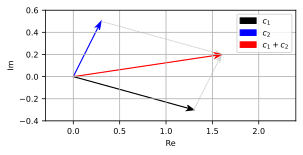

In [6]:
c1 = 1.3 - 0.3j
c2 = 0.3 + 0.5j
c = c1 + c2

generate_figure(xlim=[-0.3, 2.4], ylim=[-0.4, 0.6])
v1 = plot_vector(c1, color='k')
v2 = plot_vector(c2, color='b')
plot_vector(c1, start=c2, linestyle=':', color='lightgray')
plot_vector(c2, start=c1, linestyle=':', color='lightgray')
v3 = plot_vector(c, color='r')

plt.legend([v1, v2, v3], ['$c_1$', '$c_2$', '$c_1+c_2$']);

Complex multiplication of two numbers  $c_1=a_1+ib_1$ and $c_2=a_2+ib_2$ is defined by:

$$c = c_1 \cdot c_2 = (a_1 + ib_1) \cdot (a_2 + ib_2) := (a_1a_2 - b_1b_2) + i(a_1b_2 + b_1a_2).$$

Geometrically, the product is obtained by adding angles and by multiplying the absolute values. In other words, if $(|c_1|, \gamma_1)$ and $(|c_2|, \gamma_2)$ are the polar representations of $c_1$ and $c_1$, respectively, then the polar representation $(|c|, \gamma)$ of $c$ is given by:

\begin{eqnarray*}
\gamma &=& \gamma_1 + \gamma_2 \\
|c| &=& |c_1| \cdot |c_2|
\end{eqnarray*}

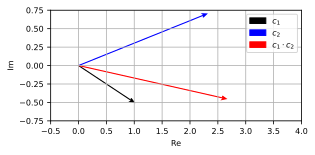

In [7]:
c1 = 1.0 - 0.5j
c2 = 2.3 + 0.7j
c = c1 * c2

generate_figure(xlim=[-0.5, 4.0], ylim=[-0.75, 0.75])
v1 = plot_vector(c1, color='k')
v2 = plot_vector(c2, color='b')
v3 = plot_vector(c, color='r')
plt.legend([v1, v2, v3], ['$c_1$', '$c_2$', r'$c_1 \cdot c_2$']);

Given a complex number $c = a + bi$, the **complex conjugation** is defined by $\overline{c} := a - bi$. Many computations can be expressed in a more compact form using the complex conjugate. The following identities hold:
As for the real and imaginary part as well as the absolute value, one has:

\begin{eqnarray*}
a &=& \frac{1}{2} (c+\overline{c}) \\
b &=& \frac{1}{2i} (c-\overline{c}) \\
|c|^2 &=& c\cdot \overline{c}\\
\overline{c_1+c_2} &=& \overline{c_1} + \overline{c_2}\\
\overline{c_1\cdot c_2} &=& \overline{c_1} \cdot \overline{c_2}
\end{eqnarray*}

Geometrically, conjugation is reflection on the real axis.

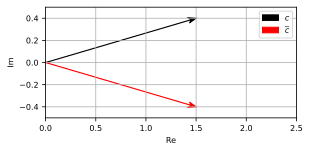

In [8]:
c = 1.5 + 0.4j
c_conj = np.conj(c)

generate_figure(xlim=[0, 2.5], ylim=[-0.5, 0.5])
v1 = plot_vector(c, color='k')
v2 = plot_vector(c_conj, color='r')

plt.legend([v1, v2], ['$c$', r'$\overline{c}$']);

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> As the previous examples showed, the library <code>matplotlib</code> allows for using certain <a href="https://matplotlib.org/stable/tutorials/text/usetex.html">LaTeX code</a> to render mathematical text in the figures. To this end, one needs to activate certain settings and uses specific encodings in order to avoid conflicts between special characters used both in Python and LateX for different purposes. In particular, the backslash <code>\</code> needs to be handled with care, which can be done by using so-called <a href="https://docs.python.org/3/reference/lexical_analysis.html ">raw strings</a> marked by <code>r'...'</code>. For further details, we refer to the <a href="https://matplotlib.org/stable/tutorials/text/usetex.html">Python documentation</a> and other tutorials available on the web.
</div>

For a non-zero complex number $c = a + bi$, there is an **inverse** complex number $c^{-1}$ with the property that $c\cdot c^{-1} = 1$. The inverse is given by:

$$c^{-1} := \frac{a}{a^2 + b^2} + i \frac{-b}{a^2 + b^2} = \frac{a}{|c|^2} + i \frac{-b}{|c|^2} = \frac{\overline{c}}{|c|^2}.$$

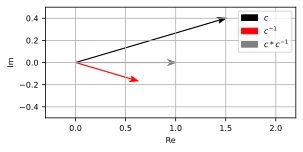

In [9]:
c = 1.5 + 0.4j
c_inv = 1 / c
c_prod = c * c_inv

generate_figure(xlim=[-0.3, 2.2], ylim=[-0.5, 0.5])
v1 = plot_vector(c, color='k')
v2 = plot_vector(c_inv, color='r')
v3 = plot_vector(c_prod, color='gray')

plt.legend([v1, v2, v3], ['$c$', '$c^{-1}$', '$c*c^{-1}$']);

With the inverse, division can be defined:
    
$$\frac{c_1}{c_2} = c_1 c_2^{-1} = \frac{a_1 + ib_1}{a_2 + ib_2} := \frac{a_1a_2 + b_1b_2}{a_2^2 + b_2^2} + i\frac{b_1a_2 - a_1b_2}{a_2^2 + b_2^2} =  \frac{c_1\cdot \overline{c_2}}{|c_2|^2}.$$

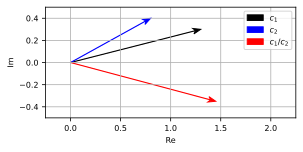

In [10]:
c1 = 1.3 + 0.3j
c2 = 0.8 + 0.4j
c = c1 / c2

generate_figure(xlim=[-0.25, 2.25], ylim=[-0.5, 0.5])
v1 = plot_vector(c1, color='k')
v2 = plot_vector(c2, color='b')
v3 = plot_vector(c, color='r')

plt.legend([v1, v2, v3], ['$c_1$', '$c_2$', '$c_1/c_2$']);

<a id='polarplot'></a> 
## Polar Coordinate Plot

Finally, we show how complex vectors can be visualized in a polar coordinate plot. Also, the following code cell illustrates some functionalities of the Python libraries `numpy` and `matplotlib`.

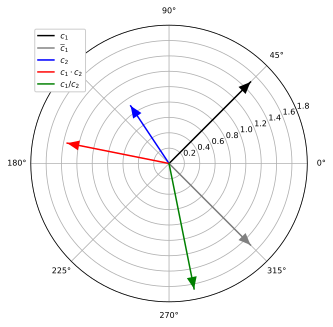

In [11]:
def plot_polar_vector(c, label=None, color=None, start=0, linestyle='-'):
    """Plot arrow in polar plot

    Notebook: PCP_06_complex.ipynb

    Args:
        c: Complex number
        label: Label of arrow (Default value = None)
        color: Color of arrow (Default value = None)
        start: Complex number encoding the start position (Default value = 0)
        linestyle: Linestyle of arrow (Default value = '-')
    """
    # plot line in polar plane
    line = plt.polar([np.angle(start), np.angle(c)], [np.abs(start), np.abs(c)], 
                     label=label, color=color, linestyle=linestyle)
    # plot arrow in same color
    this_color = line[0].get_color() if color is None else color
    plt.annotate('', xytext=(np.angle(start), np.abs(start)), 
        xy=(np.angle(c), np.abs(c)), arrowprops=dict(facecolor=this_color, 
        edgecolor='none', headlength=12, headwidth=10, shrink=1, width=0))
    
c_abs = 1.5
c_angle = 45  # in degree
c_angle_rad = np.deg2rad(c_angle) 
a = c_abs * np.cos(c_angle_rad)
b = c_abs * np.sin(c_angle_rad)
c1 = a + b*1j    
c2 = -0.5 + 0.75*1j

plt.figure(figsize=(5, 5))
plot_polar_vector(c1, label='$c_1$', color='k')
plot_polar_vector(np.conj(c1), label=r'$\overline{c}_1$', color='gray')
plot_polar_vector(c2, label='$c_2$', color='b')
plot_polar_vector(c1*c2, label=r'$c_1 \cdot c_2$', color='r')
plot_polar_vector(c1/c2, label='$c_1/c_2$', color='g')

plt.ylim([0, 1.8]);
plt.legend(framealpha=1, loc="upper left");

<a id='exercise_complex'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 1: Rotate Complex Number</strong>

<p style="color:#006064;">
Create and plot the following complex numbers using the functions described above.
</p>
<ul style="color:#006064;">
    <li>Create a complex number $c$ with an angle of $20$ degrees and an absolute value of $1.2$. Also plot its conjugate and inverse.</li>
    <li>Write a function <code>rotate_complex</code> that rotates a complex number $c$ by $r$ degrees in clockwise direction. Apply this function for $c= 1 + 0.5i$ and $r\in\{10,20, 30\}$. Plot all resulting complex numbers.</li>        
</ul>    
</div>

In [12]:
# Your Solution

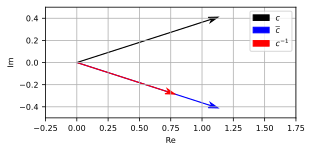

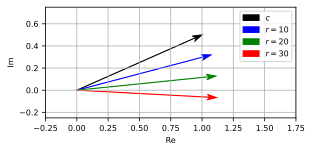

In [13]:
exercise_complex()

<a id='exercise_polynomial'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 2: Roots of Polynomial</strong>
<p style="color:#006064;">
Let $p(z)= p_0 z^N + p_1 z^{N-1} + \ldots + p_{N-1}z + p_N$ be a complex-valued polynomial of degree $N\in\mathbb{N}$ with coefficients $p_n\in\mathbb{C}$ for $n\in[0:N]$. Define a function <code>vis_root</code> that inputs a polynomial and visualizes all roots of the polynomial (i.e., all zeros of the polynomial). To compute the roots, use the <a href="https://numpy.org/doc/stable/reference/generated/numpy.roots.html">NumPy function <code>np.roots</code></a>. To encode the polynomial follow the conventions as used for <code>np.roots</code>, where the above polynomial is represented by the array <code>(p[0],p[1], ..., p[N])</code>. For the visualization, use the <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html">function <code>plt.scatter</code></a> for representing each root as a dot in the Cartesian plane. Apply the function for the following polynomials and discuss the results.       
<ul style="color:#006064;">
    <li>$p(z)=z^2-2$ (<code>p = np.array([1, 0, -2])</code>) </li>
    <li>$p(z)=z^2+2$ (<code>p = np.array([1, 0, 2])</code>) </li>
    <li>$p(z)=z^8-1$ (<code>p = np.array([1, 0, 0, 0, 0, 0, 0, 0, -1])</code>) </li>
    <li>$p(z)=z^8 + z^7 + z^6$ (<code>p = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0])</code>) </li>
    <li>$p(z)=z^8 + z^7 + z^6 + 0.000001$ (<code>p = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0.000001])</code>) </li>
    <li>$p(z)=z^3 -2iz^2 + (2+4i)z + 3 $ (<code>p = np.array([1, -2j, 2 + 4j, 3])</code>) </li>
</ul>    
</div>

In [14]:
# Your Solution

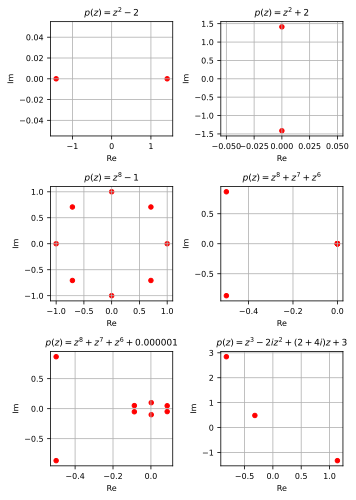

In [15]:
exercise_polynomial()

<div style="
  background-color: #FFE0B2A0;
  border: 1px solid #FFC671A0;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<p style="color:#E65100;">
<strong>Note:</strong> As another application of complex numbers, we will consider in the next exercise a construction of a subset of complex numbers known as <a href="https://en.wikipedia.org/wiki/Mandelbrot_set">Mandelbrot set</a>. As noted at <a href="https://en.wikipedia.org/wiki/Mandelbrot_set">Wikipedia</a>, images of the Mandelbrot set exhibit an elaborate and infinitely complicated boundary that reveals progressively ever-finer recursive detail at increasing magnifications, making the boundary of the Mandelbrot set a <a href="https://en.wikipedia.org/wiki/Fractal_curve">fractal curve</a>. The Mandelbrot set has become popular outside mathematics both for its aesthetic appeal and as an example of a complex structure arising from applying simple rules. It is one of the best-known examples of mathematical visualization, mathematical beauty, and motif. In practice, one cannot easily compute the Mandelbrot set. Instead, one uses iterative algorithms based on heuristics to find an approximation of the Mandelbrot set, which can then be visualized as a subset of the complex plane. Often the boundary of the Mandelbrot set (the fractal curve) and its outer neighborhood are visualized with a color-coding that expresses divergence properties. This leads to the fascinating images of the Mandelbrot set you may have encountered. On the web, you can find numerous examples of how to approximate the Mandelbrot set and visualize it (e.g., also in an interactive fashion that allows you to zoom into the Mandelbrot set). In the following exercise, we will dive into this topic of fractals and their visualization. <strong>But be careful: You may become addicted and get lost in this topic. Don't forget to continue with the other units.</strong>            
</div>

In [16]:
# ipd.display(ipd.YouTubeVideo('b005iHf8Z3g', width=480, height=360))

<a id='exercise_mandelbrot'></a>
<div style="
  background-color: #B2EBF290;
  border: 1px solid #4DD0E190;
  padding-top: 10px;
  padding-bottom: 10px;
  padding-left: 20px;
  padding-right: 20px;
  margin-top: 10px;
  margin-bottom: 10px;
">
<strong style="color:#006064; display: block; break-after: avoid; page-break-after: avoid;">Exercise 3: Mandelbrot Set</strong>
<p style="color:#006064;">
Let $c\in\mathbb{C}$ be a complex number and $f_c:\mathbb{C}\to\mathbb{C}$ the function defined by $f_c(z)=z^2+c$ for $z\in\mathbb{C}$. Starting with $z=0$, we consider the iteration $v_c(0):=f_c(0)$ and $v_c(k) := f_c(v_c(k-1))$ for $k\in\mathbb{N}$. The Mandelbrot set is the set of complex numbers $c$ for which the series $(v_c(k))_{k\in\mathbb{N}}$ stays bounded (i.e., if there is a constant $\gamma_c$ such that $v_c(k)\leq \gamma_c$ for all $k\in\mathbb{N}$. Write a function that plots the Mandelbrot set in the Cartesian plane, where a number $c$ is colored black if it belongs to the Mandelbrot set and otherwise is colored white. 
</p>
<ul style="color:#006064;">
    <li>Model the Mandelbrot set as a binary indicator function $\chi:\mathbb{C}\in\{0,1\}$, where $\chi(c)=1$ if $c$ belongs to the Mandelbrot set and $\chi(c)=0$ otherwise. </li>
    <li>Only consider complex numbers $c=a+ib$ on a discrete grid on a bounded range. It suffices to consider the range $a\in[-2,1]$ and $b\in[-1.2,1.2]$. Furthermore, for efficiency reasons, use a grid spacing that is not too fine. First, try out $\Delta a = \Delta b = 0.01$. To create the grid, you may use the function <code>np.meshgrid</code>.</li>
    <li>Test for each $c=a+ib$ on that grid, if $(v_c(k))_{k\in\mathbb{N}}$ remains bounded or not. Computationally, this cannot be tested easily. However, usually, the sequence $(v_c(k))$ increases in an exponential fashion in the case that it is not bounded. Therefore, a pragmatic (yet not always correct) test is to fix a maximum number of iterations (e.g., $K = 50$) and a threshold (e.g., $L = 100$).</li>
    <li>Plot $\chi$ using the function <code>plt.imshow</code>, use the colormap <code>'gray_r'</code>. Furthermore, use the parameter <code>extent</code> to adjust ranges of the horizontal axis $[-2,1]$ (real part) and vertical axis $[-1.2,1.2]$ (imaginary part).</li>           
</ul>    
</div>

In [17]:
# Your Solution

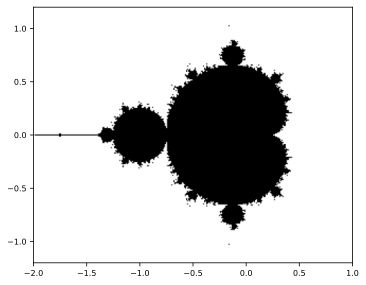

In [18]:
exercise_mandelbrot()

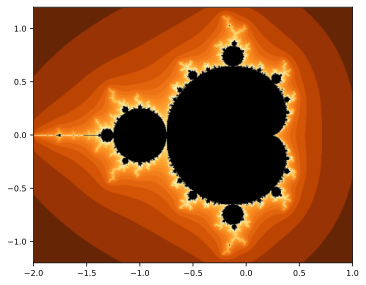

In [19]:
exercise_mandelbrot_fancy()

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCP_License.png" width=100% style="float: right;" alt="PCP License"></a>
</div>